## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [1]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


### Find no.of samples are there in training and test datasets

In [2]:
x_train.shape

(60000, 28, 28)

In [3]:
x_test.shape

(10000, 28, 28)

### Find dimensions of an image in the dataset 

Training data set is 60000 samples with 28x28 size images
Test data set is 10000 samples with 28x28 size images

Since the dataset 3rd dimension is 1, it is not a color data

x_train and x_test parts contain greyscale RGB codes (from 0 to 255) while y_train and y_test parts contains labels from 0 to 9 which represents which number they actually are


### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
import tensorflow as tf
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
#Normalize after converting to float since we are using divide by 255 to normalize
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
#Convert in to 1D vector to match input dimensions of conv2D layers
#Reshape data from 2D to 1D -> 28x28 to 784
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

### Import the necessary layers from keras to build the model

In [0]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from keras import regularizers
from keras import optimizers


import keras
import keras.utils
from keras import utils as np_utils

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [8]:
#Initialize Sequential model
model = Sequential()

#Normalize the data
model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(Flatten()) # Flattening the 2D arrays for fully connected layers
model.add(Dense(128, activation="relu"))
model.add(Dense(10,activation="softmax"))

W0818 10:57:13.597316 140571051620224 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0818 10:57:13.616019 140571051620224 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0818 10:57:13.618484 140571051620224 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.



In [9]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
flatten_1 (Flatten)          (None, 18432)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               2359424   
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1290      
Total params: 2,370,282
Trainable params: 2,370,282
Non-trainable params: 0
_________________________________________________________________


In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

W0818 10:57:13.688183 140571051620224 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0818 10:57:13.717040 140571051620224 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3295: The name tf.log is deprecated. Please use tf.math.log instead.



In [11]:
# simple early stopping
callbacks = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

model.fit(x_train, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callbacks
          )

W0818 10:57:13.819357 140571051620224 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0818 10:57:13.880026 140571051620224 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Epoch 1/10
18880/60000 [========>.....................] - ETA: 10s - loss: 0.5234 - acc: 0.8138

KeyboardInterrupt: ignored

In [0]:
model.summary()

In [0]:
model.evaluate(x_test, y_test)

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [0]:
#Initialize Sequential model
model1 = Sequential()

#Normalize the data
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model1.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(keras.layers.Dropout(0.25))

model1.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model1.add(Dense(128, activation="relu"))
model1.add(Dense(10,activation="softmax"))
model1.summary()

In [0]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# simple early stopping
callbacks1= [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

model1.fit(x_train, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callbacks1
          )

In [0]:
model1.evaluate(x_test, y_test)

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
#Initialize Sequential model
model2 = Sequential()

#Normalize the data
model2.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model2.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model2.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model2.add(keras.layers.Dropout(0.25))

model2.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model2.add(Dense(128, activation="relu"))
model2.add(Dense(10,activation="softmax"))
model2.summary()
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# simple early stopping
callbacks2 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

In [0]:
train_gen =  keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.1, 
                               shear_range=0.3, 
                               horizontal_flip=True,
                               height_shift_range=0.1, 
                               zoom_range=0.08 )

test_gen = keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.1, 
                               shear_range=0.3, 
                               horizontal_flip=True,
                               height_shift_range=0.1, 
                               zoom_range=0.08 )

training_set= train_gen.flow(x_train, y_train, batch_size=64)
test_set= train_gen.flow(x_test, y_test, batch_size=64)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

In [0]:
from matplotlib import pyplot as plt
gen = train_gen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [0]:
model2.fit_generator(training_set, 
                         steps_per_epoch=60000//64, 
                         validation_data= test_set, 
                         validation_steps=10000//64, 
                         epochs=10,
                         callbacks=callbacks2)


###  Report the final train and validation accuracy

In [0]:
model2.evaluate(x_train, y_train)

In [0]:
model2.evaluate(x_test, y_test)

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
from keras.datasets import cifar10

### **Load CIFAR10 dataset**

In [0]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [23]:
x_train.shape

(50000, 32, 32, 3)

In [24]:
x_test.shape

(10000, 32, 32, 3)

In [0]:
#Normalize after converting to float since we are using divide by 255 to normalize
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

In [0]:
input_shape = x_train.shape[1:]

In [0]:

# Convert class vectors to binary class matrices.
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
train_gen =  keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.05, 
                               shear_range=0.5, 
                               horizontal_flip=True,
                               height_shift_range=0.08, 
                               zoom_range=0.08 )

test_gen = keras.preprocessing.image.ImageDataGenerator(rotation_range=4, 
                               width_shift_range=0.05, 
                               shear_range=0.5, 
                               horizontal_flip=True,
                               height_shift_range=0.08, 
                               zoom_range=0.08 )

training_set= train_gen.flow(x_train, y_train, batch_size=64)
test_set= train_gen.flow(x_test, y_test, batch_size=64)

### **Prepare/fit the generator.**

In [0]:
#Initialize Sequential model
model3 = Sequential()

#Normalize the data
model3.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu", padding='same'))
model3.add(Conv2D(64, kernel_size=(3,3), input_shape=input_shape, activation="relu", padding='same'))
model3.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model3.add(keras.layers.Dropout(0.25))

model3.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model3.add(Dense(512, activation="relu"))
model3.add(Dense(10,activation="softmax"))
model3.summary()
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# simple early stopping
callbacks3 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

In [0]:
model3.fit_generator(training_set, 
                         steps_per_epoch=50000//32, 
                         validation_data= test_set, 
                         validation_steps=50000//32, 
                         epochs=10,
                         callbacks=callbacks3)


In [0]:
model2.evaluate(x_train, y_train)

In [0]:
model2.evaluate(x_test, y_test)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

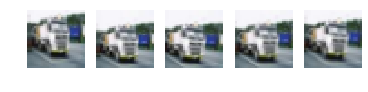

In [31]:
from matplotlib import pyplot as plt
gen = train_gen.flow(x_train[1000:1001], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze())
    plt.plot()
plt.show()